<a href="https://colab.research.google.com/github/Leelapriyaallamsetty/Data-and-business-analytics-/blob/main/Olist_data_and_business_analyst_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
print("Select the Olist Brazilian E-Commerce zip you downloaded from Kaggle")
uploaded = files.upload()  # pick the .zip

Select the Olist Brazilian E-Commerce zip you downloaded from Kaggle


Saving archive (8).zip to archive (8).zip


In [2]:
import zipfile, os

zip_name = [f for f in uploaded.keys() if f.endswith(".zip")][0]
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(".")

print("CSV files extracted:")
for f in sorted(os.listdir(".")):
    if f.endswith(".csv"):
        print(" -", f)

CSV files extracted:
 - olist_customers_dataset.csv
 - olist_geolocation_dataset.csv
 - olist_order_items_dataset.csv
 - olist_order_payments_dataset.csv
 - olist_order_reviews_dataset.csv
 - olist_orders_dataset.csv
 - olist_products_dataset.csv
 - olist_sellers_dataset.csv
 - product_category_name_translation.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [4]:
# Standard Olist filenames. If Cell 2 printed different names, edit here.
files_map = {
    "orders":       "olist_orders_dataset.csv",
    "items":        "olist_order_items_dataset.csv",
    "payments":     "olist_order_payments_dataset.csv",
    "reviews":      "olist_order_reviews_dataset.csv",
    "customers":    "olist_customers_dataset.csv",
    "sellers":      "olist_sellers_dataset.csv",
    "products":     "olist_products_dataset.csv",
    "geolocation":  "olist_geolocation_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

dfs = {}
for key, fname in files_map.items():
    dfs[key] = pd.read_csv(fname)
    print(f"{key:22s} {str(dfs[key].shape):16s}  <- {fname}")

# Convenient handles
orders   = dfs["orders"]
items    = dfs["items"]
payments = dfs["payments"]
reviews  = dfs["reviews"]
customers= dfs["customers"]
sellers  = dfs["sellers"]
products = dfs["products"]
geo      = dfs["geolocation"]
cat_tr   = dfs["category_translation"]

orders                 (99441, 8)        <- olist_orders_dataset.csv
items                  (112650, 7)       <- olist_order_items_dataset.csv
payments               (103886, 5)       <- olist_order_payments_dataset.csv
reviews                (99224, 7)        <- olist_order_reviews_dataset.csv
customers              (99441, 5)        <- olist_customers_dataset.csv
sellers                (3095, 4)         <- olist_sellers_dataset.csv
products               (32951, 9)        <- olist_products_dataset.csv
geolocation            (1000163, 5)      <- olist_geolocation_dataset.csv
category_translation   (71, 2)           <- product_category_name_translation.csv


In [5]:
for key, df in dfs.items():
    print("="*70)
    print(f"TABLE: {key}   shape={df.shape}")
    print("-"*70)
    print("Columns:", list(df.columns))
    nulls = df.isna().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print("Nulls:")
        print(nulls.to_string())
    else:
        print("Nulls: none")
    print()

TABLE: orders   shape=(99441, 8)
----------------------------------------------------------------------
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Nulls:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965

TABLE: items   shape=(112650, 7)
----------------------------------------------------------------------
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Nulls: none

TABLE: payments   shape=(103886, 5)
----------------------------------------------------------------------
Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
Nulls: none

TABLE: reviews   shape=(99224, 7)
----------------------------------------------------------------------
Columns: ['revie

In [6]:
print(">> ORDERS (the spine) — one row per order")
display(orders.head(3))

print("\n>> ORDER_ITEMS — one row per item; orders can repeat")
display(items.head(3))

print("\nItems per order (sample distribution):")
print(items.groupby("order_id").size().value_counts().head())

>> ORDERS (the spine) — one row per order


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



>> ORDER_ITEMS — one row per item; orders can repeat


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



Items per order (sample distribution):
1    88863
2     7516
3     1322
4      505
5      204
Name: count, dtype: int64


In [7]:
checks = {
    "orders.customer_id in customers": orders["customer_id"].isin(customers["customer_id"]).mean(),
    "items.order_id in orders":        items["order_id"].isin(orders["order_id"]).mean(),
    "payments.order_id in orders":     payments["order_id"].isin(orders["order_id"]).mean(),
    "reviews.order_id in orders":      reviews["order_id"].isin(orders["order_id"]).mean(),
    "items.product_id in products":    items["product_id"].isin(products["product_id"]).mean(),
    "items.seller_id in sellers":      items["seller_id"].isin(sellers["seller_id"]).mean(),
}
print("Share of keys that match across tables (1.0 = perfect):\n")
for k, v in checks.items():
    print(f"  {k:38s}: {v:.3f}")

Share of keys that match across tables (1.0 = perfect):

  orders.customer_id in customers       : 1.000
  items.order_id in orders              : 1.000
  payments.order_id in orders           : 1.000
  reviews.order_id in orders            : 1.000
  items.product_id in products          : 1.000
  items.seller_id in sellers            : 1.000


In [8]:
schema_notes = """
OLIST SCHEMA — grain of each table (one row = ...)
--------------------------------------------------
orders       : one ORDER            key: order_id      -> customer_id
items        : one ITEM in an order  key: order_id+item -> product_id, seller_id
payments     : one PAYMENT on order  key: order_id (can be >1 per order)
reviews      : one REVIEW            key: review_id     -> order_id
customers    : one CUSTOMER          key: customer_id   (+ customer_unique_id)
sellers      : one SELLER            key: seller_id
products     : one PRODUCT           key: product_id    -> category (Portuguese)
geolocation  : one ZIP-PREFIX point  key: zip_code_prefix (lat/lng)
cat_tr       : category name map     Portuguese -> English

CARDINALITY WARNINGS for Phase 2 joins:
- 1 order -> MANY items  (joining items inflates order rows; aggregate first)
- 1 order -> MANY payments (sum payment_value per order before joining)
- 1 order -> 0/1 review  (use left join; some orders have no review)
"""
print(schema_notes)


OLIST SCHEMA — grain of each table (one row = ...)
--------------------------------------------------
orders       : one ORDER            key: order_id      -> customer_id
items        : one ITEM in an order  key: order_id+item -> product_id, seller_id
payments     : one PAYMENT on order  key: order_id (can be >1 per order)
reviews      : one REVIEW            key: review_id     -> order_id
customers    : one CUSTOMER          key: customer_id   (+ customer_unique_id)
sellers      : one SELLER            key: seller_id
products     : one PRODUCT           key: product_id    -> category (Portuguese)
geolocation  : one ZIP-PREFIX point  key: zip_code_prefix (lat/lng)
cat_tr       : category name map     Portuguese -> English

CARDINALITY WARNINGS for Phase 2 joins:
- 1 order -> MANY items  (joining items inflates order rows; aggregate first)
- 1 order -> MANY payments (sum payment_value per order before joining)
- 1 order -> 0/1 review  (use left join; some orders have no review)



Phase -1

In [9]:
# Orders has 5 datetime columns
order_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

# Reviews timestamps
for col in ["review_creation_date", "review_answer_timestamp"]:
    reviews[col] = pd.to_datetime(reviews[col], errors="coerce")

# Items shipping-limit date
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"], errors="coerce")

print("Order date range:",
      orders["order_purchase_timestamp"].min(), "→",
      orders["order_purchase_timestamp"].max())
print("Dtypes OK:", orders[order_date_cols].dtypes.tolist())

Order date range: 2016-09-04 21:15:19 → 2018-10-17 17:30:18
Dtypes OK: [dtype('<M8[ns]'), dtype('<M8[ns]'), dtype('<M8[ns]'), dtype('<M8[ns]'), dtype('<M8[ns]')]


In [10]:
print(orders["order_status"].value_counts())
print("\nMissing delivered-to-customer dates:",
      orders["order_delivered_customer_date"].isna().sum())
# Most missing-delivery rows are non-'delivered' statuses (canceled, shipped, etc.) — expected
print("\nStatus of orders with no delivery date:")
print(orders[orders["order_delivered_customer_date"].isna()]["order_status"].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Missing delivered-to-customer dates: 2965

Status of orders with no delivery date:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


In [11]:
o = orders.copy()

# Actual delivery time: purchase -> delivered to customer (in days)
o["delivery_days"] = (o["order_delivered_customer_date"]
                      - o["order_purchase_timestamp"]).dt.total_seconds() / 86400

# Estimate accuracy: estimated - actual delivered (positive = arrived EARLY)
o["delivery_vs_estimate"] = (o["order_estimated_delivery_date"]
                             - o["order_delivered_customer_date"]).dt.total_seconds() / 86400

# Was it late?  (delivered after the estimate)
o["is_late"] = o["delivery_vs_estimate"] < 0

# Approval & shipping lags
o["approval_hours"] = (o["order_approved_at"]
                       - o["order_purchase_timestamp"]).dt.total_seconds() / 3600
o["carrier_handover_days"] = (o["order_delivered_carrier_date"]
                              - o["order_purchase_timestamp"]).dt.total_seconds() / 86400

# Time parts for trend analysis
o["purchase_year"]  = o["order_purchase_timestamp"].dt.year
o["purchase_month"] = o["order_purchase_timestamp"].dt.to_period("M").astype(str)
o["purchase_dow"]   = o["order_purchase_timestamp"].dt.day_name()

print(o[["delivery_days","delivery_vs_estimate","is_late"]].describe())
print("\nLate delivery rate:", f"{o['is_late'].mean()*100:.1f}%")

       delivery_days  delivery_vs_estimate
count   96476.000000          96476.000000
mean       12.558702             11.179120
std         9.546530             10.186113
min         0.533414           -188.975081
25%         6.766403              6.390000
50%        10.217755             11.948941
75%        15.720327             16.244384
max       209.628611            146.016123

Late delivery rate: 7.9%


In [12]:
# Negative delivery_days = data errors (delivered before purchase). Flag them.
bad = o[o["delivery_days"] < 0]
print("Rows with negative delivery_days:", len(bad))

# Keep only sensible delivered orders for delivery analysis (don't mutate full table)
delivered = o[(o["order_status"] == "delivered") & (o["delivery_days"] >= 0)].copy()
print("Clean delivered orders:", len(delivered))
print("Median delivery:", round(delivered["delivery_days"].median(), 1), "days")

Rows with negative delivery_days: 0
Clean delivered orders: 96470
Median delivery: 10.2 days


In [13]:
# products has Portuguese category; cat_tr maps to English
products_en = products.merge(
    cat_tr, on="product_category_name", how="left"
)
# Fill untranslated categories with the original name
products_en["product_category_name_english"] = (
    products_en["product_category_name_english"]
    .fillna(products_en["product_category_name"])
    .fillna("unknown")
)
print("Categories translated. Sample:")
print(products_en[["product_category_name","product_category_name_english"]].drop_duplicates().head(10))
print("\nUnique English categories:", products_en["product_category_name_english"].nunique())

Categories translated. Sample:
   product_category_name product_category_name_english
0             perfumaria                     perfumery
1                  artes                           art
2          esporte_lazer                sports_leisure
3                  bebes                          baby
4  utilidades_domesticas                    housewares
5  instrumentos_musicais           musical_instruments
6             cool_stuff                    cool_stuff
7       moveis_decoracao               furniture_decor
8       eletrodomesticos               home_appliances
9             brinquedos                          toys

Unique English categories: 74


In [14]:
# PAYMENTS: sum to one row per order
pay_agg = payments.groupby("order_id").agg(
    total_payment=("payment_value", "sum"),
    n_payments=("payment_value", "count"),
    max_installments=("payment_installments", "max"),
    payment_types=("payment_type", lambda s: ",".join(sorted(s.unique()))),
).reset_index()

# ITEMS: sum to one row per order (price + freight), keep item count
item_agg = items.groupby("order_id").agg(
    order_value=("price", "sum"),
    total_freight=("freight_value", "sum"),
    n_items=("price", "count"),
    n_sellers=("seller_id", "nunique"),
).reset_index()

# REVIEWS: keep one review per order (latest if duplicates)
rev_clean = (reviews.sort_values("review_creation_date")
             .drop_duplicates("order_id", keep="last")
             [["order_id","review_score","review_creation_date"]])

print("pay_agg:", pay_agg.shape, "| item_agg:", item_agg.shape, "| rev_clean:", rev_clean.shape)
display(item_agg.head(3))

pay_agg: (99440, 5) | item_agg: (98666, 5) | rev_clean: (98673, 3)


,order_id,order_value,total_freight,n_items,n_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,58.9,13.29,1,1
1,00018f77f2f0320c557190d7a144bdd3,239.9,19.93,1,1
2,000229ec398224ef6ca0657da4fc703e,199.0,17.87,1,1


In [15]:
for name, df in [("delivered", delivered), ("products_en", products_en),
                 ("pay_agg", pay_agg), ("item_agg", item_agg), ("rev_clean", rev_clean)]:
    n = df.isna().sum()
    n = n[n > 0]
    print(f"{name}: {'no nulls' if n.empty else dict(n)}")

delivered: {'order_approved_at': np.int64(14), 'order_delivered_carrier_date': np.int64(1), 'approval_hours': np.int64(14), 'carrier_handover_days': np.int64(1)}
products_en: {'product_category_name': np.int64(610), 'product_name_lenght': np.int64(610), 'product_description_lenght': np.int64(610), 'product_photos_qty': np.int64(610), 'product_weight_g': np.int64(2), 'product_length_cm': np.int64(2), 'product_height_cm': np.int64(2), 'product_width_cm': np.int64(2)}
pay_agg: no nulls
item_agg: no nulls
rev_clean: no nulls


In [16]:
# Store the cleaned objects so Phase 2 can merge them
delivered.to_pickle("clean_orders.pkl")
products_en.to_pickle("clean_products.pkl")
pay_agg.to_pickle("clean_payments.pkl")
item_agg.to_pickle("clean_items.pkl")
rev_clean.to_pickle("clean_reviews.pkl")
print("Phase 1 cleaned tables saved. Ready for Phase 2 joins.")

Phase 1 cleaned tables saved. Ready for Phase 2 joins.


Phase-2

In [17]:
import pandas as pd
import numpy as np

delivered    = pd.read_pickle("clean_orders.pkl")
products_en  = pd.read_pickle("clean_products.pkl")
pay_agg      = pd.read_pickle("clean_payments.pkl")
item_agg     = pd.read_pickle("clean_items.pkl")
rev_clean    = pd.read_pickle("clean_reviews.pkl")

# Also need raw items/customers/sellers for the item-level table
print("Reloaded. delivered:", delivered.shape)

Reloaded. delivered: (96470, 16)


In [18]:
# Start from delivered orders (the spine), left-join the aggregated pieces.
# Left joins keep every order even if it has no review/payment.
master = (delivered
    .merge(item_agg, on="order_id", how="left")     # order_value, n_items, n_sellers
    .merge(pay_agg,  on="order_id", how="left")      # total_payment, installments
    .merge(rev_clean, on="order_id", how="left")     # review_score
    .merge(customers, on="customer_id", how="left")  # customer city/state
)

print("master shape:", master.shape)
print("Row count vs delivered (should match — no inflation):",
      len(master), "==", len(delivered), "->", len(master) == len(delivered))

master shape: (96470, 30)
Row count vs delivered (should match — no inflation): 96470 == 96470 -> True


In [19]:
print("Unique orders in master:", master["order_id"].nunique())
print("Total rows in master    :", len(master))
print("  (equal = joins stayed at order grain)\n")

coverage = {
    "has order_value (items)": master["order_value"].notna().mean(),
    "has payment":             master["total_payment"].notna().mean(),
    "has review_score":        master["review_score"].notna().mean(),
    "has customer_state":      master["customer_state"].notna().mean(),
}
for k, v in coverage.items():
    print(f"  {k:28s}: {v*100:.1f}%")

Unique orders in master: 96470
Total rows in master    : 96470
  (equal = joins stayed at order grain)

  has order_value (items)     : 100.0%
  has payment                 : 100.0%
  has review_score            : 99.3%
  has customer_state          : 100.0%


In [20]:
# Here each row is one item. We DON'T aggregate — we want per-item granularity.
# Join product (English category) and seller location onto each item.
item_level = (items
    .merge(products_en[["product_id","product_category_name_english"]],
           on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left")
    # attach order date + customer state from master (order-level attributes)
    .merge(master[["order_id","purchase_month","customer_state",
                   "review_score","delivery_days","is_late"]],
           on="order_id", how="left")
)

print("item_level shape:", item_level.shape)
print("Should roughly match raw items row count:", len(items))
display(item_level[["order_id","product_category_name_english",
                    "seller_id","price","review_score"]].head(3))

item_level shape: (112650, 16)
Should roughly match raw items row count: 112650


,order_id,product_category_name_english,seller_id,price,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,48436dade18ac8b2bce089ec2a041202,58.9,5.0
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,dd7ddc04e1b6c2c614352b383efe2d36,239.9,4.0
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,5b51032eddd242adc84c38acab88f23d,199.0,5.0


In [21]:
# master only has delivered orders; filter item_level to match for consistent analysis
delivered_ids = set(master["order_id"])
item_level = item_level[item_level["order_id"].isin(delivered_ids)].copy()
print("item_level (delivered only):", item_level.shape)

item_level (delivered only): (110189, 16)


In [22]:
print("=== MASTER (order-level) ===")
print("Rows:", len(master), "| Unique orders:", master["order_id"].nunique())
print("Columns:", list(master.columns))

print("\n=== ITEM_LEVEL ===")
print("Rows:", len(item_level), "| Unique orders:", item_level["order_id"].nunique())

# Spot-check: total revenue should match between the two views
rev_master = master["order_value"].sum()
rev_items  = item_level["price"].sum()
print(f"\nRevenue cross-check:")
print(f"  master order_value sum : {rev_master:,.0f}")
print(f"  item_level price sum   : {rev_items:,.0f}")
print(f"  (small diffs OK if some orders had no item rows)")

=== MASTER (order-level) ===
Rows: 96470 | Unique orders: 96470
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'delivery_vs_estimate', 'is_late', 'approval_hours', 'carrier_handover_days', 'purchase_year', 'purchase_month', 'purchase_dow', 'order_value', 'total_freight', 'n_items', 'n_sellers', 'total_payment', 'n_payments', 'max_installments', 'payment_types', 'review_score', 'review_creation_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

=== ITEM_LEVEL ===
Rows: 110189 | Unique orders: 96470

Revenue cross-check:
  master order_value sum : 13,220,249
  item_level price sum   : 13,220,249
  (small diffs OK if some orders had no item rows)


In [23]:
master.to_pickle("master_orders.pkl")
item_level.to_pickle("item_level.pkl")
print("Phase 2 complete — master_orders.pkl and item_level.pkl saved.")
print("master:", master.shape, "| item_level:", item_level.shape)

Phase 2 complete — master_orders.pkl and item_level.pkl saved.
master: (96470, 30) | item_level: (110189, 16)


Phase-3

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

master     = pd.read_pickle("master_orders.pkl")
item_level = pd.read_pickle("item_level.pkl")

def human(n):
    if pd.isna(n): return "—"
    for u in ["", "K", "M", "B"]:
        if abs(n) < 1000: return f"{n:.1f}{u}"
        n /= 1000
    return f"{n:.1f}T"
fmt = FuncFormatter(lambda x, pos: human(x))

print("master:", master.shape, "| item_level:", item_level.shape)

master: (96470, 30) | item_level: (110189, 16)


In [25]:
kpis = {
    "Total delivered orders": f"{master['order_id'].nunique():,}",
    "Total revenue (items)":   "R$ " + human(master["order_value"].sum()),
    "Avg order value":         f"R$ {master['order_value'].mean():.2f}",
    "Median delivery days":    f"{master['delivery_days'].median():.1f}",
    "Late delivery rate":      f"{master['is_late'].mean()*100:.1f}%",
    "Avg review score":        f"{master['review_score'].mean():.2f} / 5",
    "Unique product categories": item_level["product_category_name_english"].nunique(),
    "States covered":          master["customer_state"].nunique(),
}
print("="*48)
print("  OLIST E-COMMERCE — KEY METRICS")
print("="*48)
for k, v in kpis.items():
    print(f"  {k:28s}: {v}")
print("="*48)

  OLIST E-COMMERCE — KEY METRICS
  Total delivered orders      : 96,470
  Total revenue (items)       : R$ 13.2M
  Avg order value             : R$ 137.04
  Median delivery days        : 10.2
  Late delivery rate          : 8.1%
  Avg review score            : 4.16 / 5
  Unique product categories   : 74
  States covered              : 27


In [26]:
# Monthly orders & revenue
monthly = (master.groupby("purchase_month")
           .agg(orders=("order_id","nunique"),
                revenue=("order_value","sum"))
           .reset_index().sort_values("purchase_month"))

# Review score distribution
review_dist = master["review_score"].value_counts().sort_index()

# Top 12 categories by revenue
cat_rev = (item_level.groupby("product_category_name_english")["price"]
           .sum().sort_values(ascending=False).head(12))

# Top 12 states by order count
state_orders = (master["customer_state"].value_counts().head(12))

# Payment type split (explode the comma-joined types)
pay_split = (master["payment_types"].dropna()
             .str.split(",").explode().value_counts())

# Delivery days distribution (cap outliers at 60 for readability)
deliv = master["delivery_days"].clip(upper=60)

print("Analysis tables ready.")

Analysis tables ready.


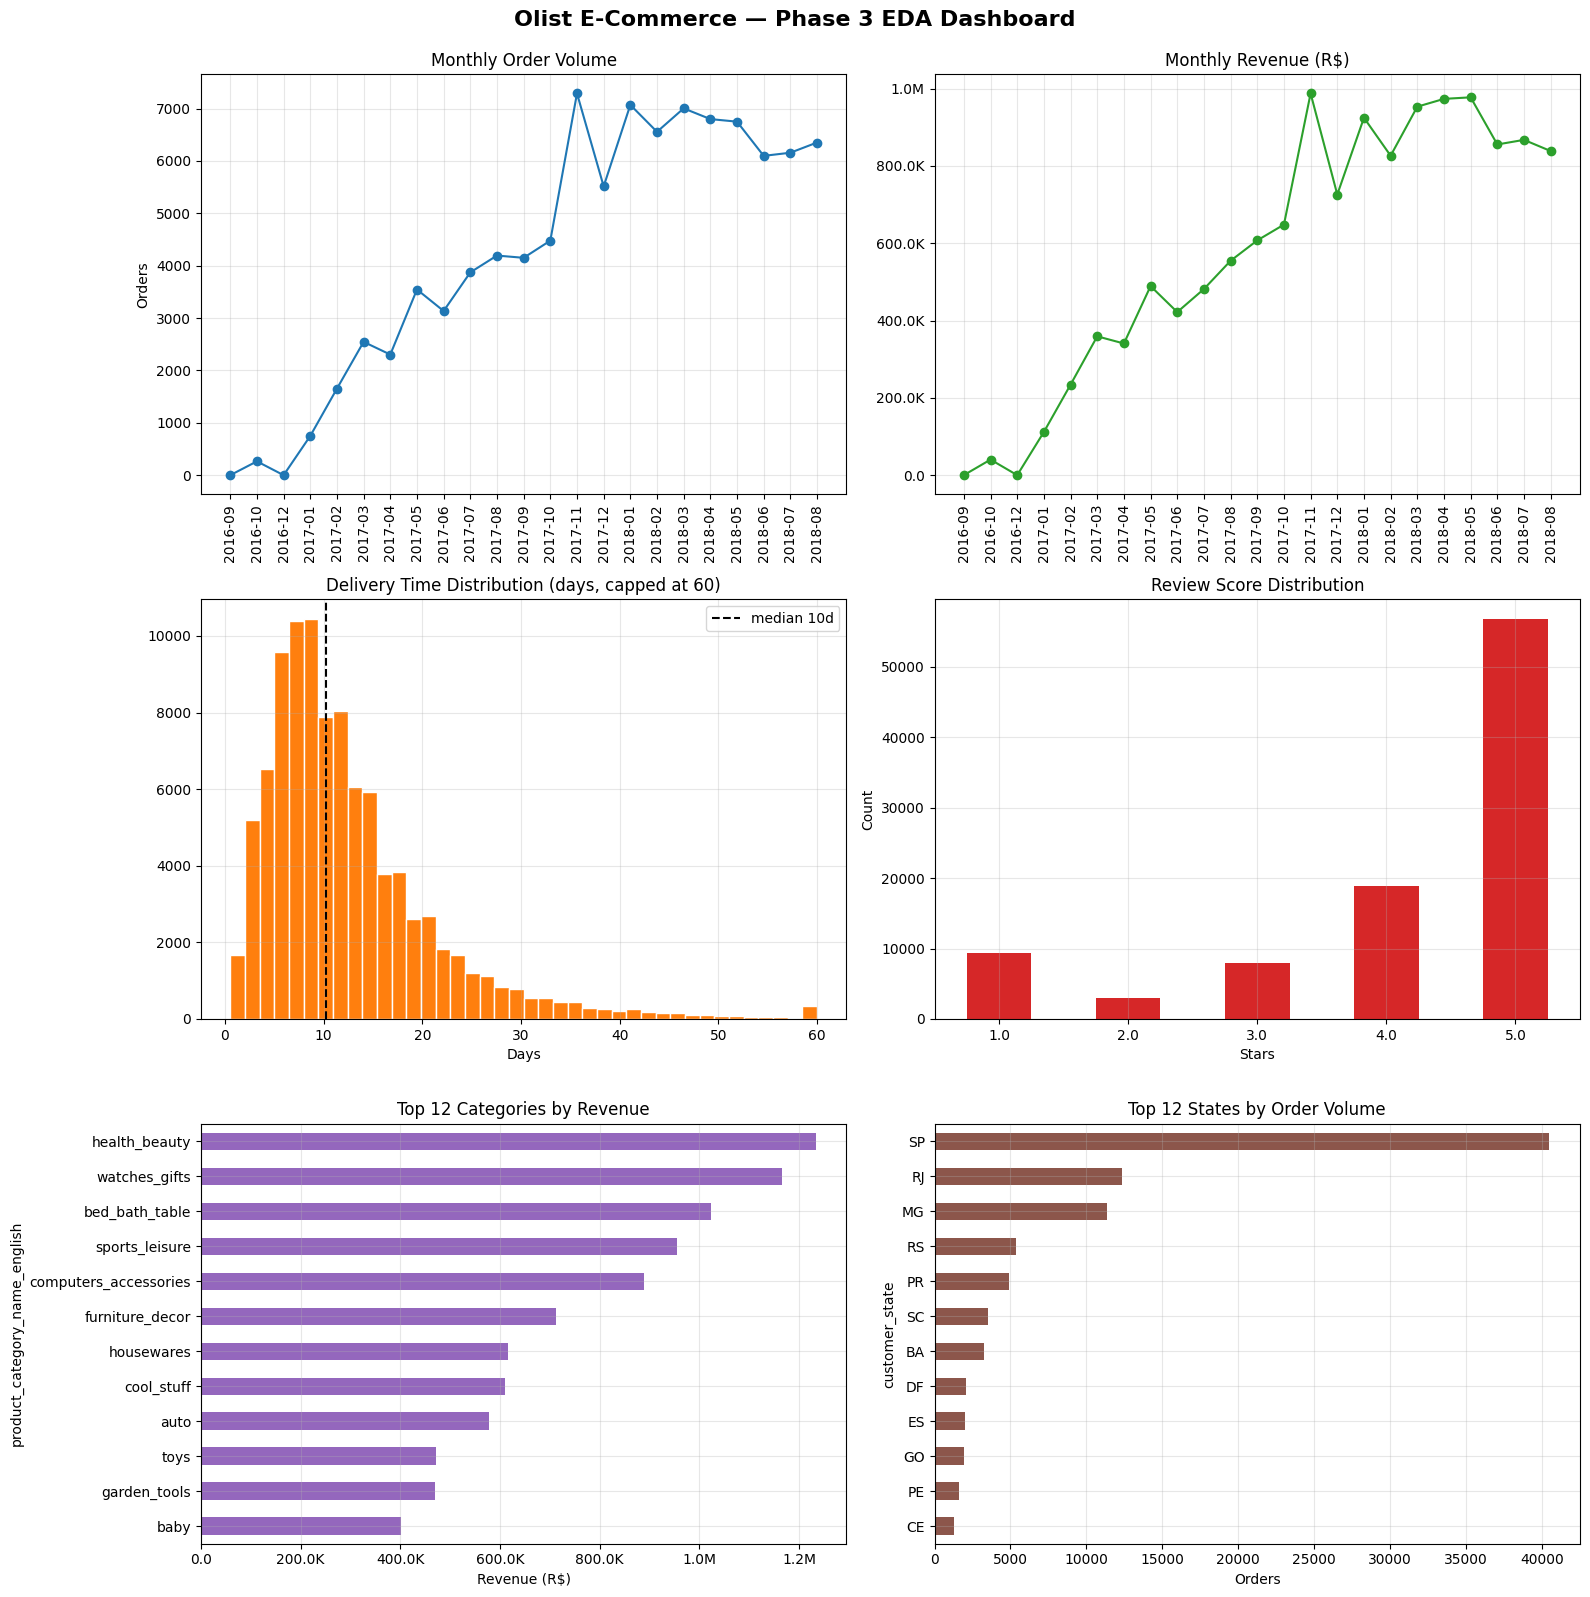

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle("Olist E-Commerce — Phase 3 EDA Dashboard",
             fontsize=16, fontweight="bold", y=0.995)

# (1) Monthly orders trend
ax = axes[0,0]
ax.plot(monthly["purchase_month"], monthly["orders"], marker="o", color="#1f77b4")
ax.set_title("Monthly Order Volume")
ax.set_xlabel(""); ax.set_ylabel("Orders")
ax.tick_params(axis="x", rotation=90)

# (2) Monthly revenue trend
ax = axes[0,1]
ax.plot(monthly["purchase_month"], monthly["revenue"], marker="o", color="#2ca02c")
ax.set_title("Monthly Revenue (R$)")
ax.set_xlabel(""); ax.yaxis.set_major_formatter(fmt)
ax.tick_params(axis="x", rotation=90)

# (3) Delivery-days distribution
ax = axes[1,0]
ax.hist(deliv.dropna(), bins=40, color="#ff7f0e", edgecolor="white")
ax.axvline(deliv.median(), color="black", linestyle="--",
           label=f"median {deliv.median():.0f}d")
ax.set_title("Delivery Time Distribution (days, capped at 60)")
ax.set_xlabel("Days"); ax.legend()

# (4) Review score distribution
ax = axes[1,1]
review_dist.plot(kind="bar", ax=ax, color="#d62728", rot=0)
ax.set_title("Review Score Distribution")
ax.set_xlabel("Stars"); ax.set_ylabel("Count")

# (5) Top categories by revenue
ax = axes[2,0]
cat_rev.sort_values().plot(kind="barh", ax=ax, color="#9467bd")
ax.set_title("Top 12 Categories by Revenue")
ax.set_xlabel("Revenue (R$)"); ax.xaxis.set_major_formatter(fmt)

# (6) Top states by orders
ax = axes[2,1]
state_orders.sort_values().plot(kind="barh", ax=ax, color="#8c564b")
ax.set_title("Top 12 States by Order Volume")
ax.set_xlabel("Orders")

plt.tight_layout()
plt.show()

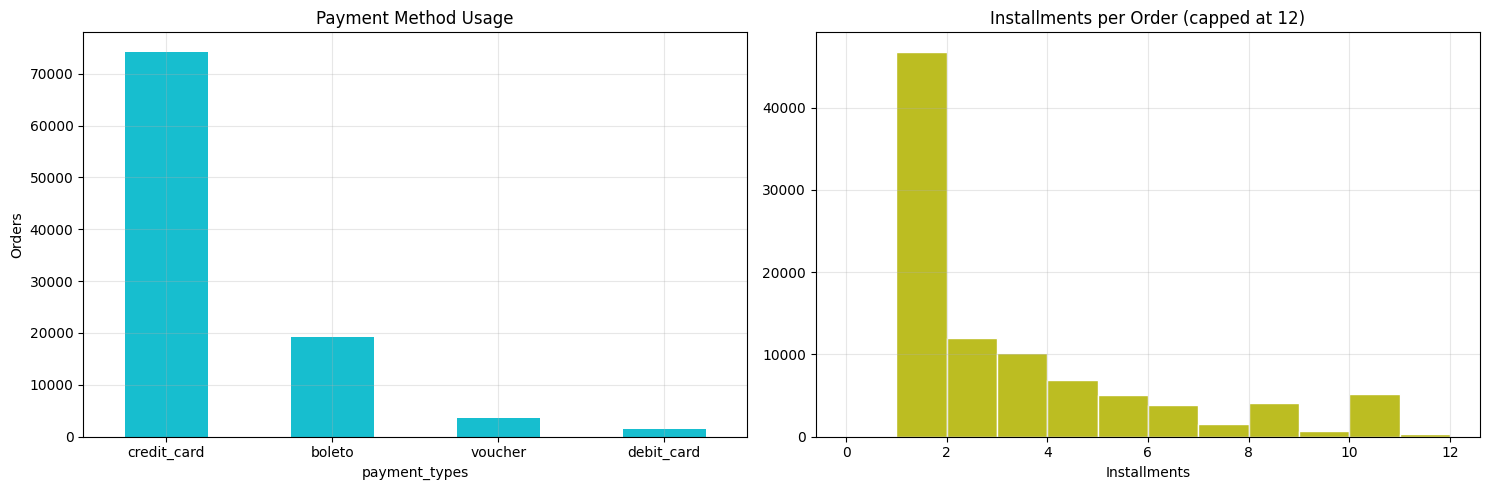

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pay_split.plot(kind="bar", ax=axes[0], color="#17becf", rot=0)
axes[0].set_title("Payment Method Usage"); axes[0].set_ylabel("Orders")

# Installments distribution
inst = master["max_installments"].dropna().clip(upper=12)
axes[1].hist(inst, bins=12, color="#bcbd22", edgecolor="white")
axes[1].set_title("Installments per Order (capped at 12)")
axes[1].set_xlabel("Installments")

plt.tight_layout(); plt.show()

In [29]:
# Does late delivery hurt review scores? Quick group comparison.
late_vs_score = master.groupby("is_late")["review_score"].mean()
print("Average review score:")
print(f"  On-time deliveries : {late_vs_score.get(False, float('nan')):.2f}")
print(f"  Late deliveries    : {late_vs_score.get(True, float('nan')):.2f}")
print("\n(We'll quantify this properly in Phase 4.)")

Average review score:
  On-time deliveries : 4.29
  Late deliveries    : 2.57

(We'll quantify this properly in Phase 4.)


Phase 4

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

master     = pd.read_pickle("master_orders.pkl")
item_level = pd.read_pickle("item_level.pkl")

def human(n):
    if pd.isna(n): return "—"
    for u in ["", "K", "M", "B"]:
        if abs(n) < 1000: return f"{n:.1f}{u}"
        n /= 1000
    return f"{n:.1f}T"
fmt = FuncFormatter(lambda x, pos: human(x))
print("Loaded. master:", master.shape, "| item_level:", item_level.shape)

Loaded. master: (96470, 30) | item_level: (110189, 16)


Review score by delivery speed:


/tmp/ipykernel_4146/2711279555.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_bucket = m.groupby("delivery_bucket").agg(


,delivery_bucket,avg_score,n_orders
0,0-5d,4.447510,13374
1,6-10d,4.362050,32885
2,11-15d,4.266425,23470
3,16-20d,4.128095,12077
4,21-30d,3.684919,9588
5,30d+,2.252596,4430



On-time vs late:


,mean,count
is_late,,
False,4.294001,88163
True,2.565331,7661



Correlation (days-early vs score): 0.267


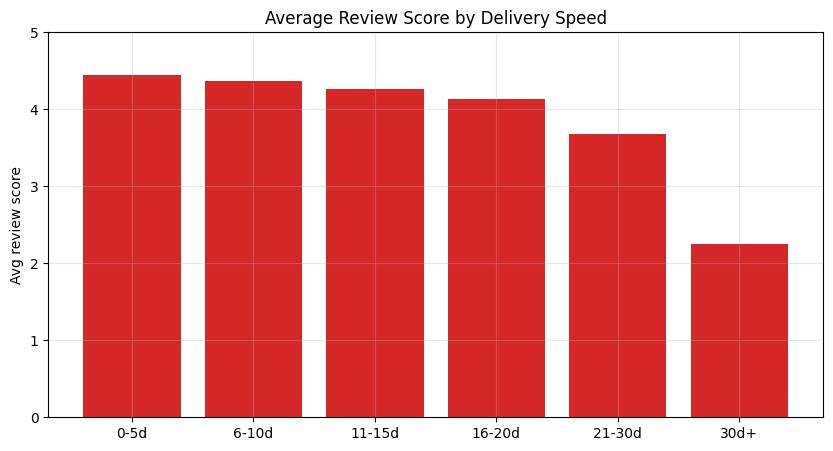

In [31]:
# Bucket delivery speed and see how review score responds
m = master.dropna(subset=["review_score","delivery_days"]).copy()
m["delivery_bucket"] = pd.cut(m["delivery_days"],
    bins=[-1,5,10,15,20,30,1000],
    labels=["0-5d","6-10d","11-15d","16-20d","21-30d","30d+"])

by_bucket = m.groupby("delivery_bucket").agg(
    avg_score=("review_score","mean"),
    n_orders=("review_score","count")).reset_index()

# Also the early/late effect
by_late = m.groupby("is_late")["review_score"].agg(["mean","count"])

print("Review score by delivery speed:")
display(by_bucket)
print("\nOn-time vs late:")
display(by_late)

# Correlation: lateness (days early/late) vs score
corr = m["delivery_vs_estimate"].corr(m["review_score"])
print(f"\nCorrelation (days-early vs score): {corr:.3f}")

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(by_bucket["delivery_bucket"].astype(str), by_bucket["avg_score"], color="#d62728")
ax.set_title("Average Review Score by Delivery Speed")
ax.set_ylabel("Avg review score"); ax.set_ylim(0,5)
plt.show()

Active sellers (>=20 orders): 804

Top 10 sellers by revenue:


,seller_id,revenue,n_orders,avg_score,late_rate
834,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1124,4.139474,0.115854
982,53243585a1d6dc2643021fd1853d8905,217940.44,348,4.128141,0.04
858,4a3ca9315b744ce9f8e9374361493884,196882.12,1772,3.826674,0.1098
2903,fa1c13f2614d7b5c4749cbc52fecda94,190917.14,578,4.373913,0.1019
1480,7c67e1448b00f6e969d365cea6b010ab,186570.05,973,3.346696,0.095941
1504,7e93a43ef30c4f03f38b393420bc753a,165981.49,319,4.364486,0.055901
2543,da8622b14eb17ae2831f4ac5b9dab84a,159816.87,1311,4.071336,0.072997
1450,7a67c85e85bb2ce8582c35f2203ad736,139658.69,1145,4.269398,0.058874
188,1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,910,3.862216,0.092254
1758,955fee9216a65b617aa5c0531780ce60,131836.71,1261,4.088235,0.080842


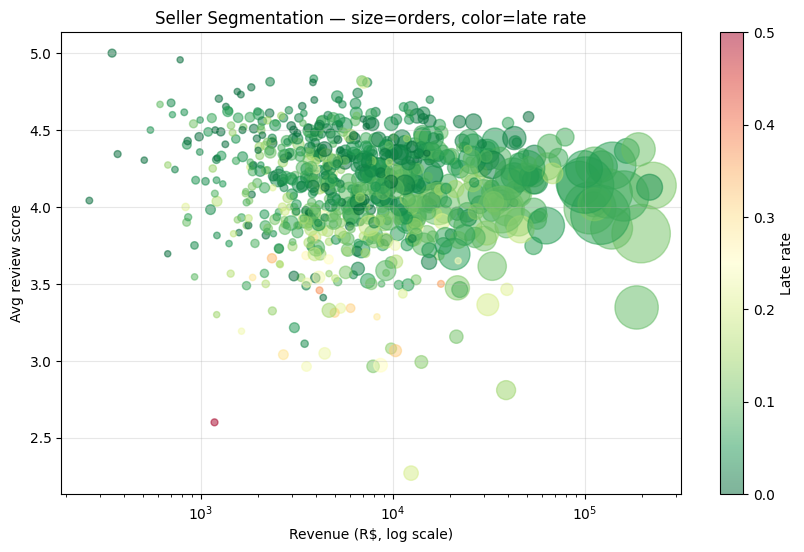

In [32]:
# Per-seller: revenue, order count, avg review, late rate
seller_perf = item_level.groupby("seller_id").agg(
    revenue=("price","sum"),
    n_items=("price","count"),
    n_orders=("order_id","nunique"),
    avg_score=("review_score","mean"),
    late_rate=("is_late","mean"),
).reset_index()

# Focus on meaningful sellers (>=20 orders)
active = seller_perf[seller_perf["n_orders"] >= 20].copy()

print("Active sellers (>=20 orders):", len(active))
print("\nTop 10 sellers by revenue:")
display(active.sort_values("revenue", ascending=False).head(10)
        [["seller_id","revenue","n_orders","avg_score","late_rate"]])

# Segmentation: high revenue but poor scores = risk
fig, ax = plt.subplots(figsize=(10,6))
sc = ax.scatter(active["revenue"], active["avg_score"],
                s=active["n_orders"], alpha=0.5,
                c=active["late_rate"], cmap="RdYlGn_r")
ax.set_xscale("log")
ax.set_xlabel("Revenue (R$, log scale)"); ax.set_ylabel("Avg review score")
ax.set_title("Seller Segmentation — size=orders, color=late rate")
plt.colorbar(sc, label="Late rate")
plt.show()

Top 10 states by revenue:


,customer_state,orders,revenue,avg_delivery,late_rate,avg_score
25,SP,40494,5066562.98,8.76,0.06,4.25
18,RJ,12350,1759651.13,15.31,0.13,3.97
10,MG,11354,1552481.83,12.01,0.06,4.19
22,RS,5344,728718.47,15.30,0.07,4.18
17,PR,4923,666063.51,11.99,0.05,4.24
23,SC,3546,507012.13,14.95,0.10,4.13
4,BA,3256,493584.14,19.34,0.14,3.93
6,DF,2080,296498.41,12.97,0.07,4.13
8,GO,1957,282836.70,15.61,0.08,4.10
7,ES,1995,268643.45,15.79,0.12,4.08


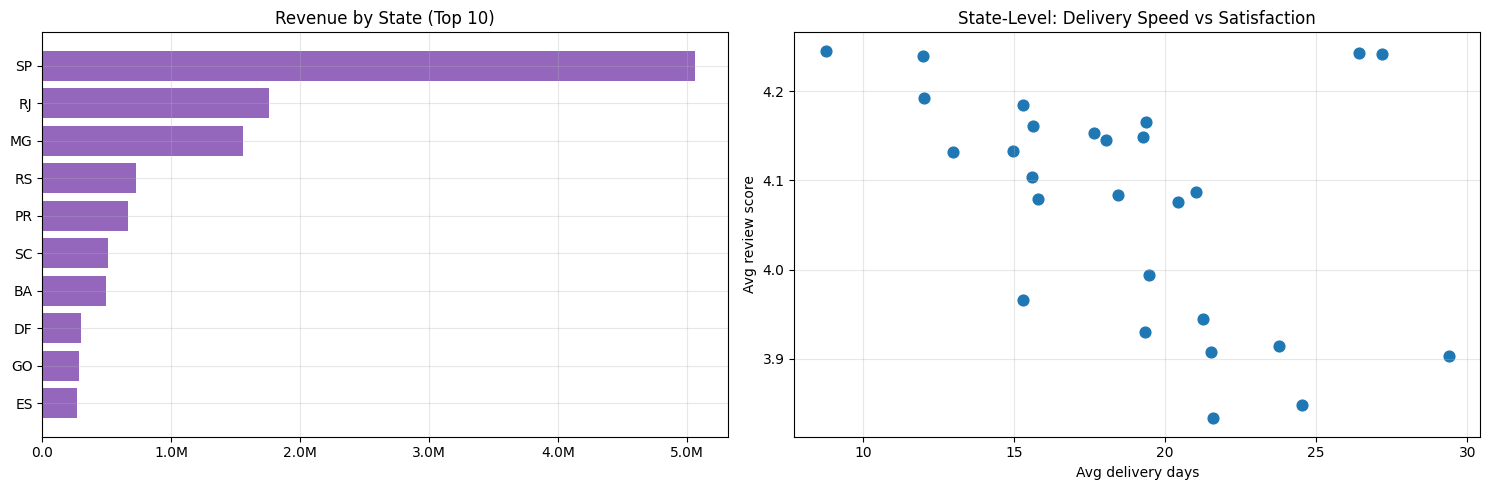

In [33]:
state_analysis = master.groupby("customer_state").agg(
    orders=("order_id","nunique"),
    revenue=("order_value","sum"),
    avg_delivery=("delivery_days","mean"),
    late_rate=("is_late","mean"),
    avg_score=("review_score","mean"),
).reset_index().sort_values("revenue", ascending=False)

print("Top 10 states by revenue:")
display(state_analysis.head(10).round(2))

fig, axes = plt.subplots(1, 2, figsize=(15,5))
top10 = state_analysis.head(10)
axes[0].barh(top10["customer_state"][::-1], top10["revenue"][::-1], color="#9467bd")
axes[0].set_title("Revenue by State (Top 10)")
axes[0].xaxis.set_major_formatter(fmt)

# Delivery speed vs satisfaction across states
axes[1].scatter(state_analysis["avg_delivery"], state_analysis["avg_score"],
                s=60, color="#1f77b4")
axes[1].set_xlabel("Avg delivery days"); axes[1].set_ylabel("Avg review score")
axes[1].set_title("State-Level: Delivery Speed vs Satisfaction")
plt.tight_layout(); plt.show()

In [34]:
cat_analysis = item_level.groupby("product_category_name_english").agg(
    revenue=("price","sum"),
    n_items=("price","count"),
    avg_price=("price","mean"),
    avg_freight=("freight_value","mean"),
    avg_score=("review_score","mean"),
).reset_index()
cat_analysis = cat_analysis[cat_analysis["n_items"] >= 50]  # meaningful volume

print("Top 10 categories by revenue:")
display(cat_analysis.sort_values("revenue", ascending=False).head(10).round(2))

print("\nLowest-rated categories (>=50 items):")
display(cat_analysis.sort_values("avg_score").head(8)
        [["product_category_name_english","avg_score","revenue","n_items"]].round(2))

Top 10 categories by revenue:


,product_category_name_english,revenue,n_items,avg_price,avg_freight,avg_score
43,health_beauty,1233131.72,9465,130.28,18.91,4.19
73,watches_gifts,1165898.98,5857,199.06,16.75,4.07
7,bed_bath_table,1023434.76,10953,93.44,18.42,3.92
67,sports_leisure,954673.55,8430,113.25,19.38,4.17
15,computers_accessories,888613.62,7643,116.27,18.84,3.99
39,furniture_decor,711927.69,8160,87.25,20.64,3.95
49,housewares,615628.69,6795,90.60,21.01,4.11
20,cool_stuff,610204.10,3718,164.12,21.91,4.20
5,auto,578849.35,4139,139.85,21.86,4.11
71,toys,471097.49,4029,116.93,18.80,4.21



Lowest-rated categories (>=50 items):


,product_category_name_english,avg_score,revenue,n_items
57,office_furniture,3.51,268154.31,1668
34,fixed_telephony,3.76,55315.21,255
30,fashion_male_clothing,3.76,10452.33,125
4,audio,3.84,50570.60,362
47,home_confort,3.85,58008.45,429
7,bed_bath_table,3.92,1023434.76,10953
40,furniture_living_room,3.93,67350.70,495
72,unknown,3.94,170726.63,1537


Order value by installment count:


/tmp/ipykernel_4146/3336400307.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_inst = inst_analysis.groupby("inst_bucket").agg(


,inst_bucket,avg_order_value,n_orders
0,1,99.94,46811
1,2-3,114.05,22157
2,4-6,157.04,15736
3,7-12,300.12,11584
4,12+,375.67,179


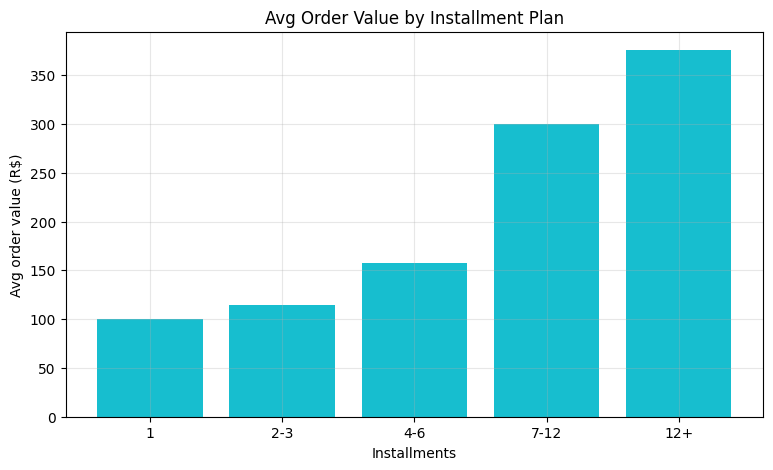

In [35]:
# Do installments correlate with bigger orders?
inst_analysis = master.dropna(subset=["max_installments","order_value"]).copy()
inst_analysis["inst_bucket"] = pd.cut(inst_analysis["max_installments"],
    bins=[0,1,3,6,12,100], labels=["1","2-3","4-6","7-12","12+"])

by_inst = inst_analysis.groupby("inst_bucket").agg(
    avg_order_value=("order_value","mean"),
    n_orders=("order_id","count")).reset_index()

print("Order value by installment count:")
display(by_inst.round(2))

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(by_inst["inst_bucket"].astype(str), by_inst["avg_order_value"], color="#17becf")
ax.set_title("Avg Order Value by Installment Plan")
ax.set_xlabel("Installments"); ax.set_ylabel("Avg order value (R$)")
plt.show()

In [36]:
summary_lines = [
    "="*55,
    "  OLIST E-COMMERCE — BUSINESS ANALYTICS SUMMARY",
    "="*55,
    f"  Delivered orders analyzed : {master['order_id'].nunique():,}",
    f"  Total revenue             : R$ {human(master['order_value'].sum())}",
    f"  Avg review score          : {master['review_score'].mean():.2f} / 5",
    f"  Late delivery rate        : {master['is_late'].mean()*100:.1f}%",
    "",
    "  KEY FINDINGS:",
    f"  1. On-time orders score {by_late.loc[False,'mean']:.2f} vs "
        f"{by_late.loc[True,'mean']:.2f} for late — delivery drives satisfaction.",
    f"  2. Revenue concentrates in top states; remote regions lag on delivery & scores.",
    f"  3. {len(active)} active sellers; a subset are high-revenue but low-rated (risk).",
    f"  4. Installment plans correlate with larger order values.",
    "="*55,
]
print("\n".join(summary_lines))

  OLIST E-COMMERCE — BUSINESS ANALYTICS SUMMARY
  Delivered orders analyzed : 96,470
  Total revenue             : R$ 13.2M
  Avg review score          : 4.16 / 5
  Late delivery rate        : 8.1%

  KEY FINDINGS:
  1. On-time orders score 4.29 vs 2.57 for late — delivery drives satisfaction.
  2. Revenue concentrates in top states; remote regions lag on delivery & scores.
  3. 804 active sellers; a subset are high-revenue but low-rated (risk).
  4. Installment plans correlate with larger order values.


Phase -5

In [37]:
import pandas as pd

master     = pd.read_pickle("master_orders.pkl")
item_level = pd.read_pickle("item_level.pkl")

# Recompute the key figures so this cell stands alone
by_late = master.groupby("is_late")["review_score"].mean()
state_rev = master.groupby("customer_state")["order_value"].sum().sort_values(ascending=False)

findings = pd.DataFrame([
    ["Delivered orders", f"{master['order_id'].nunique():,}"],
    ["Total revenue (R$)", f"{master['order_value'].sum():,.0f}"],
    ["Avg order value (R$)", f"{master['order_value'].mean():.2f}"],
    ["Avg review score", f"{master['review_score'].mean():.2f}"],
    ["Late delivery rate", f"{master['is_late'].mean()*100:.1f}%"],
    ["On-time avg score", f"{by_late.loc[False]:.2f}"],
    ["Late avg score", f"{by_late.loc[True]:.2f}"],
    ["Satisfaction gap (on-time − late)", f"{by_late.loc[False]-by_late.loc[True]:.2f}"],
    ["Top state by revenue", state_rev.index[0]],
    ["Categories analyzed", item_level["product_category_name_english"].nunique()],
], columns=["Metric", "Value"])

findings.to_csv("olist_key_findings.csv", index=False)
print(findings.to_string(index=False))

                           Metric      Value
                 Delivered orders     96,470
               Total revenue (R$) 13,220,249
             Avg order value (R$)     137.04
                 Avg review score       4.16
               Late delivery rate       8.1%
                On-time avg score       4.29
                   Late avg score       2.57
Satisfaction gap (on-time − late)       1.73
             Top state by revenue         SP
              Categories analyzed         74


/tmp/ipykernel_4146/3960915221.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_scores = m.groupby("delivery_bucket")["review_score"].mean()


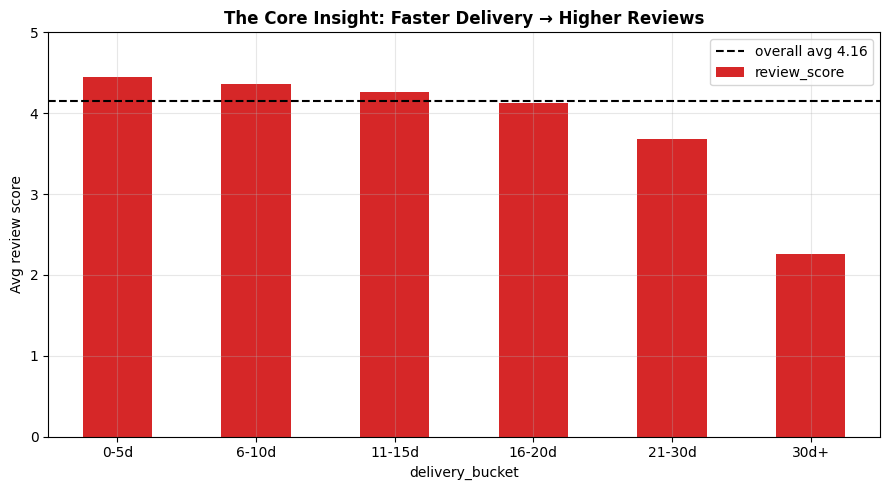

Saved olist_core_insight.png


In [38]:
import matplotlib.pyplot as plt

m = master.dropna(subset=["review_score","delivery_days"]).copy()
m["delivery_bucket"] = pd.cut(m["delivery_days"],
    bins=[-1,5,10,15,20,30,1000],
    labels=["0-5d","6-10d","11-15d","16-20d","21-30d","30d+"])
bucket_scores = m.groupby("delivery_bucket")["review_score"].mean()

fig, ax = plt.subplots(figsize=(9,5))
bucket_scores.plot(kind="bar", ax=ax, color="#d62728", rot=0)
ax.set_title("The Core Insight: Faster Delivery → Higher Reviews", fontweight="bold")
ax.set_ylabel("Avg review score"); ax.set_ylim(0,5)
ax.axhline(master["review_score"].mean(), ls="--", color="black",
           label=f"overall avg {master['review_score'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.savefig("olist_core_insight.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved olist_core_insight.png")